In [1]:
pip install yfinance 

Note: you may need to restart the kernel to use updated packages.


C:\Users\HP\AppData\Local\Temp\ipykernel_11076\428111483.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


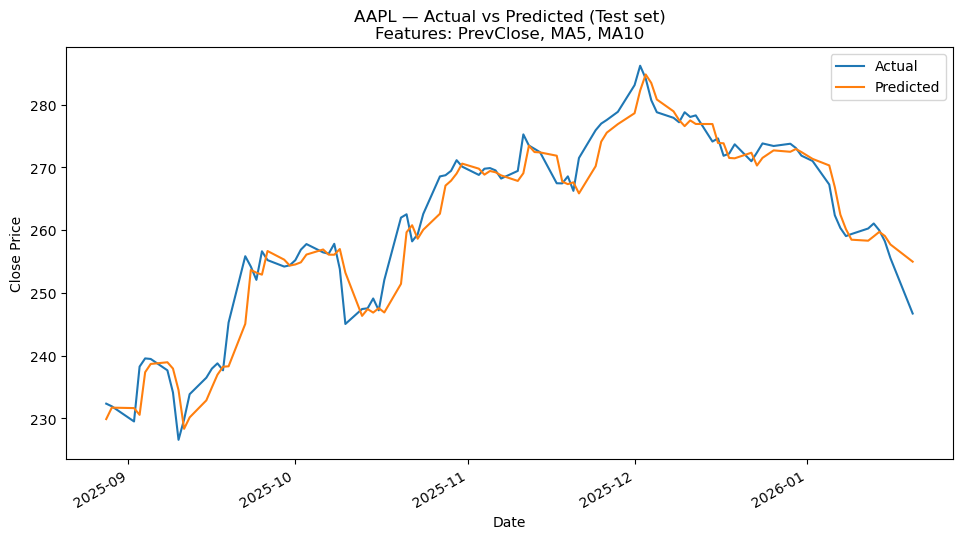

In [3]:


import tkinter as tk
from tkinter import ttk, messagebox
from datetime import datetime, timedelta
import threading

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

# ---- Helper functions ----
def fetch_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    if df.empty:
        raise ValueError("No data returned for this ticker/date range.")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.reset_index(inplace=True)
    return df

def prepare_features(df, use_prev_close=True, use_ma5=True, use_ma10=True, use_volume=True):
    data = df.copy()
    # Previous close
    if use_prev_close:
        data['PrevClose'] = data['Close'].shift(1)
    # Moving averages
    if use_ma5:
        data['MA5'] = data['Close'].rolling(window=5).mean()
    if use_ma10:
        data['MA10'] = data['Close'].rolling(window=10).mean()
    # Volume
    if use_volume:
        data['Vol'] = data['Volume']
    # Drop rows with NaN (from shifting/rolling)
    data = data.dropna().reset_index(drop=True)
    # Features and target
    feature_cols = [c for c in ['PrevClose','MA5','MA10','Vol'] if c in data.columns]
    X = data[feature_cols].copy()
    y = data['Close'].copy()
    return data, X, y, feature_cols

# ---- GUI App ----
class StockPredictorApp(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Stock Price Prediction (scikit-learn)")
        self.geometry("980x720")
        self.resizable(False, False)

        self.create_widgets()
        self.model = None
        self.last_data = None

    def create_widgets(self):
        frm = ttk.Frame(self, padding=10)
        frm.pack(fill=tk.BOTH, expand=True)

        # Inputs
        left = ttk.Frame(frm)
        left.grid(row=0, column=0, sticky="nw", padx=(0,10))

        ttk.Label(left, text="Ticker (e.g., AAPL):").grid(row=0, column=0, sticky="w")
        self.ticker_var = tk.StringVar(value="AAPL")
        ttk.Entry(left, textvariable=self.ticker_var, width=12).grid(row=0, column=1, sticky="w", pady=4)

        ttk.Label(left, text="Start Date (YYYY-MM-DD):").grid(row=1, column=0, sticky="w")
        self.start_var = tk.StringVar(value=(datetime.now() - timedelta(days=365*2)).strftime("%Y-%m-%d"))
        ttk.Entry(left, textvariable=self.start_var, width=12).grid(row=1, column=1, sticky="w", pady=4)

        ttk.Label(left, text="End Date (YYYY-MM-DD):").grid(row=2, column=0, sticky="w")
        self.end_var = tk.StringVar(value=datetime.now().strftime("%Y-%m-%d"))
        ttk.Entry(left, textvariable=self.end_var, width=12).grid(row=2, column=1, sticky="w", pady=4)

        # Features
        ttk.Label(left, text="Features:").grid(row=3, column=0, sticky="w", pady=(10,0))
        self.ch_prev = tk.BooleanVar(value=True)
        self.ch_ma5 = tk.BooleanVar(value=True)
        self.ch_ma10 = tk.BooleanVar(value=True)
        self.ch_vol = tk.BooleanVar(value=False)
        ttk.Checkbutton(left, text="Previous Close", variable=self.ch_prev).grid(row=4, column=0, columnspan=2, sticky="w")
        ttk.Checkbutton(left, text="5-day MA", variable=self.ch_ma5).grid(row=5, column=0, columnspan=2, sticky="w")
        ttk.Checkbutton(left, text="10-day MA", variable=self.ch_ma10).grid(row=6, column=0, columnspan=2, sticky="w")
        ttk.Checkbutton(left, text="Volume", variable=self.ch_vol).grid(row=7, column=0, columnspan=2, sticky="w")

        # Train/Test split
        ttk.Label(left, text="Test size (0-1):").grid(row=8, column=0, sticky="w", pady=(10,0))
        self.testsize_var = tk.DoubleVar(value=0.2)
        ttk.Entry(left, textvariable=self.testsize_var, width=6).grid(row=8, column=1, sticky="w")

        # Buttons
        self.train_btn = ttk.Button(left, text="Train & Evaluate", command=self.on_train)
        self.train_btn.grid(row=9, column=0, columnspan=2, pady=(12,6), sticky="we")

        self.predict_btn = ttk.Button(left, text="Predict Next Day Close", command=self.on_predict_next, state=tk.DISABLED)
        self.predict_btn.grid(row=10, column=0, columnspan=2, pady=(0,6), sticky="we")

        self.save_btn = ttk.Button(left, text="Save Model (.pkl)", command=self.on_save_model, state=tk.DISABLED)
        self.save_btn.grid(row=11, column=0, columnspan=2, pady=(0,6), sticky="we")

        # Metrics display
        right = ttk.Frame(frm)
        right.grid(row=0, column=1, sticky="ne")

        metrics = ttk.LabelFrame(right, text="Model Metrics", padding=10)
        metrics.pack(fill=tk.BOTH, expand=False)
        ttk.Label(metrics, text="Mean Squared Error:").grid(row=0, column=0, sticky="w")
        self.mse_lbl = ttk.Label(metrics, text="N/A")
        self.mse_lbl.grid(row=0, column=1, sticky="w", padx=8)

        ttk.Label(metrics, text="R² Score:").grid(row=1, column=0, sticky="w")
        self.r2_lbl = ttk.Label(metrics, text="N/A")
        self.r2_lbl.grid(row=1, column=1, sticky="w", padx=8)

        ttk.Label(metrics, text="Trained On:").grid(row=2, column=0, sticky="w")
        self.rows_lbl = ttk.Label(metrics, text="N/A")
        self.rows_lbl.grid(row=2, column=1, sticky="w", padx=8)

        # Plot area
        plot_frame = ttk.Frame(frm)
        plot_frame.grid(row=1, column=0, columnspan=2, pady=(12,0))

        self.fig, self.ax = plt.subplots(figsize=(9.6,5.4))
        plt.tight_layout()
        self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
        self.canvas.get_tk_widget().pack()

        # Status bar
        self.status_var = tk.StringVar(value="Ready")
        statusbar = ttk.Label(self, textvariable=self.status_var, relief=tk.SUNKEN, anchor="w")
        statusbar.pack(side=tk.BOTTOM, fill=tk.X)

    def set_status(self, s):
        self.status_var.set(s)
        self.update_idletasks()

    def on_train(self):
        # Run training in a thread to avoid freezing the GUI
        thread = threading.Thread(target=self.train_and_evaluate)
        thread.start()

    def train_and_evaluate(self):
        try:
            self.set_status("Fetching data...")
            ticker = self.ticker_var.get().strip().upper()
            start = self.start_var.get().strip()
            end = self.end_var.get().strip()
            # Validation
            try:
                _ = datetime.strptime(start, "%Y-%m-%d")
                _ = datetime.strptime(end, "%Y-%m-%d")
            except ValueError:
                messagebox.showerror("Invalid Date", "Please use YYYY-MM-DD format for dates.")
                self.set_status("Ready")
                return

            df = fetch_stock_data(ticker, start, end)
            self.set_status("Preparing features...")
            data, X, y, features = prepare_features(df,
                                                   use_prev_close=self.ch_prev.get(),
                                                   use_ma5=self.ch_ma5.get(),
                                                   use_ma10=self.ch_ma10.get(),
                                                   use_volume=self.ch_vol.get())

            if X.shape[0] < 30:
                messagebox.showwarning("Too little data", "Not enough rows after feature preparation. Try a longer date range or fewer features.")
                self.set_status("Ready")
                return

            test_size = float(self.testsize_var.get())
            if not 0.0 < test_size < 1.0:
                messagebox.showerror("Invalid test size", "Enter a test size between 0 and 1 (e.g., 0.2).")
                self.set_status("Ready")
                return

            # Train/test split without shuffling (time series)
            split_idx = int(len(X) * (1 - test_size))
            X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
            y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

            self.set_status("Training model...")
            model = LinearRegression()
            model.fit(X_train.values, y_train.values)

            self.set_status("Predicting...")
            y_pred = model.predict(X_test.values)

            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            # Update GUI
            self.model = model
            self.last_data = (data, X, y, features)
            self.mse_lbl.config(text=f"{mse:.4f}")
            self.r2_lbl.config(text=f"{r2:.4f}")
            self.rows_lbl.config(text=f"{len(X_train)} train / {len(X_test)} test")
            self.predict_btn.config(state=tk.NORMAL)
            self.save_btn.config(state=tk.NORMAL)

            # Plot
            self.ax.clear()
            # Plot actual vs predicted for test period
            test_dates = data['Date'].iloc[-len(y_test):]
            self.ax.plot(test_dates, y_test.values, label="Actual", linewidth=1.5)
            self.ax.plot(test_dates, y_pred, label="Predicted", linewidth=1.5)
            self.ax.set_title(f"{ticker} — Actual vs Predicted (Test set)\nFeatures: {', '.join(features)}")
            self.ax.set_xlabel("Date")
            self.ax.set_ylabel("Close Price")
            self.ax.legend()
            self.fig.autofmt_xdate()
            self.canvas.draw()

            self.set_status("Training completed.")
        except Exception as e:
            messagebox.showerror("Error", str(e))
            self.set_status("Ready")

    def on_predict_next(self):
        if self.model is None or self.last_data is None:
            messagebox.showinfo("Not ready", "Train the model first.")
            return
        data, X, y, features = self.last_data
        # Build the last row's features to predict next day
        last_row = data.iloc[-1:].copy()
        # We need the exact same features as used to train - build them from the data
        # For PrevClose, it's the last close; for MA, compute over the existing data
        # For a simple next-day predict, use the last available PrevClose/MA values
        feature_values = []
        if 'PrevClose' in features:
            feature_values.append(last_row['Close'].values[0])
        if 'MA5' in features:
            feature_values.append(data['Close'].rolling(5).mean().iloc[-1])
        if 'MA10' in features:
            feature_values.append(data['Close'].rolling(10).mean().iloc[-1])
        if 'Vol' in features:
            feature_values.append(last_row['Volume'].values[0])

        # If any MA is NaN (not enough history), warn user
        if any(pd.isna(feature_values)):
            messagebox.showwarning("Insufficient history", "Not enough historical rows to compute moving averages for next-day prediction.")
            return

        X_next = np.array(feature_values).reshape(1, -1)
        pred = self.model.predict(X_next)[0]
        messagebox.showinfo("Next Day Prediction", f"Predicted next-day Close: {pred:.4f}")

    def on_save_model(self):
        import pickle, time
        if self.model is None:
            messagebox.showinfo("No model", "Train a model first.")
            return
        fname = f"lr_model_{self.ticker_var.get().strip().upper()}_{int(time.time())}.pkl"
        with open(fname, "wb") as f:
            pickle.dump({
                "model": self.model,
                "features": self.last_data[3],
            }, f)
        messagebox.showinfo("Model saved", f"Model saved to {fname}")

# ---- Run the app ----
if __name__ == "__main__":
    app = StockPredictorApp()
    app.mainloop()
